In [124]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.metrics import precision_recall_curve, f1_score
 
from sklearn.impute import SimpleImputer
 



In [125]:
df = pd.read_csv('../data/processed/pns_2019_final.csv')
df.shape

(87657, 78)

In [126]:
df = df.dropna()
df.shape

(74304, 78)

In [127]:
df.info()

<class 'pandas.DataFrame'>
Index: 74304 entries, 0 to 87655
Data columns (total 78 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   situacao_domicilio      74304 non-null  int64  
 1   acesso_internet         74304 non-null  int64  
 2   plano_saude             74304 non-null  float64
 3   hipertensao             74304 non-null  float64
 4   diabetes                74304 non-null  float64
 5   doenca_coracao          74304 non-null  float64
 6   infarto                 74304 non-null  float64
 7   angina                  74304 non-null  float64
 8   insuficiencia_cardiaca  74304 non-null  float64
 9   arritmia                74304 non-null  float64
 10  avc                     74304 non-null  float64
 11  asma                    74304 non-null  float64
 12  artrite                 74304 non-null  float64
 13  dort                    74304 non-null  float64
 14  depressao               74304 non-null  float64
 15  d

In [128]:
# Contagem absoluta
contagem = df["hipertensao"].value_counts(dropna=False)

# Proporção
proporcao = (
    df["hipertensao"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

resumo = pd.DataFrame({
    "qtd": contagem,
    "percentual_%": proporcao
})

resumo

,qtd,percentual_%
hipertensao,,
0.0,52146,70.18
1.0,22158,29.82


In [129]:
df["hipertensao"].value_counts(normalize=True)

hipertensao
0.0    0.701793
1.0    0.298207
Name: proportion, dtype: float64

### Testar Interações entre Variaveis


In [130]:
# verifica valores de situacao_domicilio
# hipertensao               27.052396
# depressao                  9.329592
# diabetes                   8.352152
df["hipertensao"].value_counts()

hipertensao
0.0    52146
1.0    22158
Name: count, dtype: int64

In [131]:
df["esc_x_idade"] = df["escolaridade_ord"] * df["idade_c"] 
df["renda_x_idade"] = df["renda_per_capita_log"] * df["idade_c"] 
df["atividade_x_idade"] = df["atividade_ativo"] * df["idade_c"] 
df["tabagismo_x_idade"] = df["tabagismo_status"] * df["idade_c"] 
df["alcool_x_idade"] = df["alcool_ativo"] * df["idade_c"] 
df["imc_x_idade"] = df["imc"] * df["idade_c"]  
df["plano_x_idade"] = df["plano_saude"] * df["idade_c"]  
df["situacao_x_idade"] = df["situacao_domicilio"] * df["idade_c"]  
df["sexo_x_idade"] = df["sexo_feminino"] * df["idade_c"] 
df["renda_x_imc"] = df["renda_per_capita_log"] * df["imc"]
df["indice_socioeconomico_x_idade"] = df["indice_socioeconomico"] * df["idade_c"]
df["raca_Preta_x_idade"] = df["raca_Preta"] * df["idade_c"]
df["raca_Parda_x_idade"] = df["raca_Parda"] * df["idade_c"]
df["raca_Amarela_x_idade"] = df["raca_Amarela"] * df["idade_c"]
df["raca_Indigena_x_idade"] = df["raca_Indigena"] * df["idade_c"]

# =====================================================================
# 1. BLOCO DEMOGRÁFICO (Variáveis de Ajuste / Baseline Epidemiológico)
# =====================================================================
# Estas variáveis estarão presentes em TODOS os modelos para garantir 
# que estamos controlando os fatores invariáveis/estruturais básicos.
features_base_demo = [
    "idade_c",
    "sexo_feminino",
    "raca_Preta",
    "raca_Parda",
    "raca_Amarela",
    "raca_Indigena"
]

features_x_idade_demo = [
    "sexo_x_idade",
    "raca_Preta_x_idade",
    "raca_Parda_x_idade",
    "raca_Amarela_x_idade",
    "raca_Indigena_x_idade"
]

# =====================================================================
# 2. BLOCO BIOMÉDICO E COMPORTAMENTAL
# =====================================================================
features_base_bio = [
    "atividade_ativo",
    "tabagismo_ativo",
    "alcool_ativo",
    "imc"
]

features_x_idade_bio = [
    "atividade_x_idade",
    "tabagismo_x_idade",
    "alcool_x_idade",
    "imc_x_idade"
]

# =====================================================================
# 3. BLOCO DETERMINANTES SOCIAIS DA SAÚDE (DSS Puro)
# =====================================================================
features_base_dss = [
    "escolaridade_ord", 
    "renda_per_capita_log", 
    "plano_saude",
    "situacao_domicilio",
]

features_x_idade_dss = [
    "esc_x_idade",  
    "renda_x_idade",    
    "plano_x_idade",
    "situacao_x_idade",
    "indice_socioeconomico_x_idade"
]

# =====================================================================
# 4. COMPOSIÇÃO FINAL DOS MODELOS 
# =====================================================================

# Modelo 1: Bio + Demo (O "padrão" dos algoritmos atuais que queremos criticar)
features_final_bio = features_base_demo + features_x_idade_demo + features_base_bio + features_x_idade_bio

# Modelo 2: DSS + Demo (Isola o impacto puramente social, sem exames clínicos/imc)
features_final_dss = features_base_demo + features_x_idade_demo + features_base_dss + features_x_idade_dss

# Modelo 3: Completo (O estado da arte, integrando clínica, demografia e social)
features_final_dss_bio = features_base_demo + features_x_idade_demo + features_base_bio + features_x_idade_bio + features_base_dss + features_x_idade_dss


## Criar matriz X

In [132]:
# Modelo 1: DSS
X_bio = df[features_final_bio]
X_dss_bio = df[features_final_dss_bio]
X_dss = df[features_final_dss]
 

## Definir variavel alvo

In [133]:
y = df["hipertensao"]

In [134]:
# Modelo 1
X_bio_train, X_bio_test, y_bio_train, y_bio_test = train_test_split(
    X_bio, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

 

X_dss_bio_train, X_dss_bio_test, y_dss_bio_train, y_dss_bio_test = train_test_split(
    X_dss_bio, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_dss_train, X_dss_test, y_dss_train, y_dss_test = train_test_split(
    X_dss, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# smote = SMOTE(random_state=42)
# X_bio_resampled, y_bio_resampled = smote.fit_resample(X_bio_train, y_bio_train)
# X_dss_bio_resampled, y_dss_bio_resampled = smote.fit_resample(X_dss_bio_train, y_dss_bio_train)
# X_dss_resampled, y_dss_resampled = smote.fit_resample(X_dss_train, y_dss_train)
 

## Padronização
Lasso necessita de escala padronizada

In [135]:
# scaler_bio = StandardScaler()
# scaler_dss = StandardScaler()
# scaler_dss_bio = StandardScaler()

# # Modelo 1
# X_bio_train_scaled = scaler_bio.fit_transform(X_bio_train)
# X_bio_test_scaled = scaler_bio.transform(X_bio_test)

# # Modelo 2: DSS + BIO
# X_dss_bio_train_scaled = scaler_dss_bio.fit_transform(X_dss_bio_train)
# X_dss_bio_test_scaled = scaler_dss_bio.transform(X_dss_bio_test)

# # MODELO 3: DSS
# X_dss_train_scaled = scaler_dss.fit_transform(X_dss_train)
# X_dss_test_scaled = scaler_dss.transform(X_dss_test)


In [136]:
pipeline_bio = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(
        penalty='l1',
        solver='saga',
        cv=5,
        scoring='roc_auc',
        max_iter=5000,
        class_weight='balanced'
    ))
])

pipeline_dss = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(
        penalty='l1',
        solver='saga',
        cv=5,
        scoring='roc_auc',
        max_iter=5000,
        class_weight='balanced'
    ))
])

pipeline_dss_bio = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(
        penalty='l1',
        solver='saga',
        cv=5,
        scoring='roc_auc',
        max_iter=5000,
        class_weight='balanced'
    ))
])

In [137]:
pipeline_bio.fit(X_bio_train, y_bio_train)
pipeline_dss.fit(X_dss_train, y_dss_train)
pipeline_dss_bio.fit(X_dss_bio_train, y_dss_bio_train)

d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## Treinar Modelo LASSO L1
usar cross validation para escolher λ automaticamente



Melhor threshold pelo F1: 0.51
              precision    recall  f1-score   support

         0.0       0.86      0.73      0.79     10429
         1.0       0.53      0.73      0.61      4432

    accuracy                           0.73     14861
   macro avg       0.70      0.73      0.70     14861
weighted avg       0.76      0.73      0.74     14861



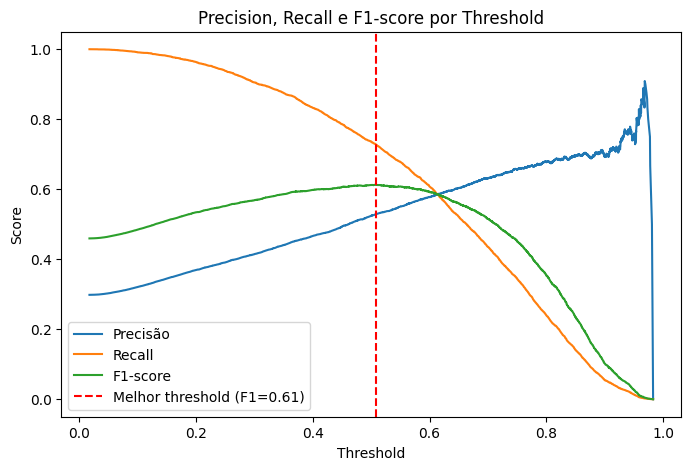

In [138]:

y_bio_prob = pipeline_bio.predict_proba(X_bio_test)[:, 1]

precisions_bio, recalls_bio, thresholds_bio = precision_recall_curve(y_bio_test, y_bio_prob)
f1_bio_scores = 2 * (precisions_bio * recalls_bio) / (precisions_bio + recalls_bio + 1e-8)

best_idx_bio = f1_bio_scores[:-1].argmax()
best_threshold_bio = thresholds_bio[best_idx_bio]
print(f"Melhor threshold pelo F1: {best_threshold_bio:.2f}")
print(classification_report(y_bio_test, (y_bio_prob >= best_threshold_bio).astype(int)))

plt.figure(figsize=(8,5))
plt.plot(thresholds_bio, precisions_bio[:-1], label='Precisão')
plt.plot(thresholds_bio, recalls_bio[:-1], label='Recall')
plt.plot(thresholds_bio, f1_bio_scores[:-1], label='F1-score')
plt.axvline(best_threshold_bio, color='red', linestyle='--', label=f'Melhor threshold (F1={f1_bio_scores[best_idx_bio]:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall e F1-score por Threshold')
plt.legend()
plt.show()

Melhor threshold pelo F1: 0.48
              precision    recall  f1-score   support

         0.0       0.86      0.66      0.75     10429
         1.0       0.49      0.75      0.59      4432

    accuracy                           0.69     14861
   macro avg       0.67      0.71      0.67     14861
weighted avg       0.75      0.69      0.70     14861



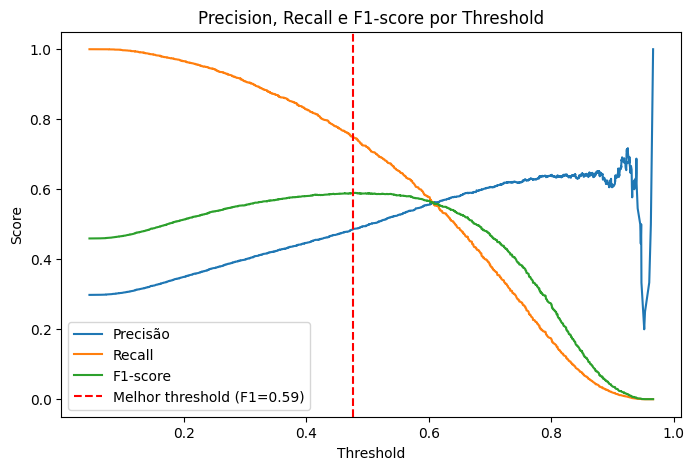

In [139]:

y_prob_dss = pipeline_dss.predict_proba(X_dss_test)[:, 1]

precisions_dss, recalls_dss, thresholds_dss = precision_recall_curve(y_dss_test, y_prob_dss)
f1_dss_scores = 2 * (precisions_dss * recalls_dss) / (precisions_dss + recalls_dss + 1e-8)

best_idx_dss = f1_dss_scores[:-1].argmax()
best_threshold_dss = thresholds_dss[best_idx_dss]
print(f"Melhor threshold pelo F1: {best_threshold_dss:.2f}")
print(classification_report(y_dss_test, (y_prob_dss >= best_threshold_dss).astype(int)))

plt.figure(figsize=(8,5))
plt.plot(thresholds_dss, precisions_dss[:-1], label='Precisão')
plt.plot(thresholds_dss, recalls_dss[:-1], label='Recall')
plt.plot(thresholds_dss, f1_dss_scores[:-1], label='F1-score')
plt.axvline(best_threshold_dss, color='red', linestyle='--', label=f'Melhor threshold (F1={f1_dss_scores[best_idx_dss]:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall e F1-score por Threshold')
plt.legend()
plt.show()

Melhor threshold pelo F1: 0.50
              precision    recall  f1-score   support

         0.0       0.87      0.71      0.78     10429
         1.0       0.52      0.75      0.61      4432

    accuracy                           0.72     14861
   macro avg       0.69      0.73      0.70     14861
weighted avg       0.76      0.72      0.73     14861



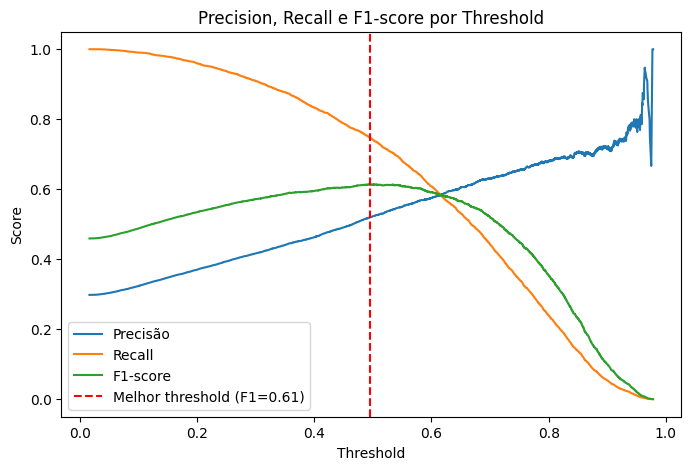

In [140]:
# Modelo DSS + BIO

y_prob_dss_bio = pipeline_dss_bio.predict_proba(X_dss_bio_test)[:, 1]

precisions_dss_bio, recalls_dss_bio, thresholds_dss_bio = precision_recall_curve(y_dss_bio_test, y_prob_dss_bio)
f1_dss_bio_scores = 2 * (precisions_dss_bio * recalls_dss_bio) / (precisions_dss_bio + recalls_dss_bio + 1e-8)

best_idx_dss_bio = f1_dss_bio_scores[:-1].argmax()
best_threshold_dss_bio = thresholds_dss_bio[best_idx_dss_bio]
print(f"Melhor threshold pelo F1: {best_threshold_dss_bio:.2f}")
print(classification_report(y_dss_bio_test, (y_prob_dss_bio >= best_threshold_dss_bio).astype(int)))

plt.figure(figsize=(8,5))
plt.plot(thresholds_dss_bio, precisions_dss_bio[:-1], label='Precisão')
plt.plot(thresholds_dss_bio, recalls_dss_bio[:-1], label='Recall')
plt.plot(thresholds_dss_bio, f1_dss_bio_scores[:-1], label='F1-score')
plt.axvline(best_threshold_dss_bio, color='red', linestyle='--', label=f'Melhor threshold (F1={f1_dss_bio_scores[best_idx_dss_bio]:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall e F1-score por Threshold')
plt.legend()
plt.show()

In [141]:
# Usar o melhor threshold encontrado para predições e métricas finais
# y_proba já foi calculado anteriormente

y_pred_otimo = (y_bio_prob >= best_threshold_bio).astype(int)

print("Relatório de classificação com threshold ótimo para BIO:")
print(classification_report(y_bio_test, y_pred_otimo))
print("Matriz de confusão:")
print(confusion_matrix(y_bio_test, y_pred_otimo))

Relatório de classificação com threshold ótimo para BIO:
              precision    recall  f1-score   support

         0.0       0.86      0.73      0.79     10429
         1.0       0.53      0.73      0.61      4432

    accuracy                           0.73     14861
   macro avg       0.70      0.73      0.70     14861
weighted avg       0.76      0.73      0.74     14861

Matriz de confusão:
[[7564 2865]
 [1209 3223]]


In [142]:
# Usar o melhor threshold encontrado para predições e métricas finais
# y_proba já foi calculado anteriormente

y_dss_otimo = (y_prob_dss >= best_threshold_dss).astype(int)

print("Relatório de classificação com threshold ótimo para DSS:")
print(classification_report(y_dss_test, y_dss_otimo))
print("Matriz de confusão:")
print(confusion_matrix(y_dss_test, y_dss_otimo))

Relatório de classificação com threshold ótimo para DSS:
              precision    recall  f1-score   support

         0.0       0.86      0.66      0.75     10429
         1.0       0.49      0.75      0.59      4432

    accuracy                           0.69     14861
   macro avg       0.67      0.71      0.67     14861
weighted avg       0.75      0.69      0.70     14861

Matriz de confusão:
[[6923 3506]
 [1112 3320]]


In [143]:
# Usar o melhor threshold encontrado para predições e métricas finais
# y_proba já foi calculado anteriormente

y_dss_bio_otimo = (y_prob_dss_bio >= best_threshold_dss_bio).astype(int)

print("Relatório de classificação com threshold ótimo para DSS + BIO:")
print(classification_report(y_dss_bio_test, y_dss_bio_otimo))
print("Matriz de confusão:")
print(confusion_matrix(y_dss_bio_test, y_dss_bio_otimo))

Relatório de classificação com threshold ótimo para DSS + BIO:
              precision    recall  f1-score   support

         0.0       0.87      0.71      0.78     10429
         1.0       0.52      0.75      0.61      4432

    accuracy                           0.72     14861
   macro avg       0.69      0.73      0.70     14861
weighted avg       0.76      0.72      0.73     14861

Matriz de confusão:
[[7377 3052]
 [1117 3315]]


## Avaliação 

### Predição

In [144]:
y_bio_pred = pipeline_bio.predict(X_bio_test)
y_prob = pipeline_bio.predict_proba(X_bio_test)[:,1]

In [145]:
y_dss_pred = pipeline_dss.predict(X_dss_test)
y_dss_prob = pipeline_dss.predict_proba(X_dss_test)[:,1]

In [146]:
y_dss_bio_pred = pipeline_dss_bio.predict(X_dss_bio_test)
y_dss_bio_prob = pipeline_dss_bio.predict_proba(X_dss_bio_test)[:,1]

### Métricas

In [147]:
print("MODELO BIOMEDICO")
print("AUC:", roc_auc_score(y_bio_test, y_bio_prob))
print("Accuracy:", accuracy_score(y_bio_test, y_bio_pred))
print(classification_report(y_bio_test, y_bio_pred))

MODELO BIOMEDICO
AUC: 0.7920943011416721
Accuracy: 0.7220240898997375
              precision    recall  f1-score   support

         0.0       0.86      0.72      0.78     10429
         1.0       0.52      0.74      0.61      4432

    accuracy                           0.72     14861
   macro avg       0.69      0.73      0.70     14861
weighted avg       0.76      0.72      0.73     14861



In [148]:
print("MODELO DSS")
print("AUC:", roc_auc_score(y_dss_test, y_dss_prob))
print("Accuracy:", accuracy_score(y_dss_test, y_dss_pred))
print(classification_report(y_dss_test, y_dss_pred))

MODELO DSS
AUC: 0.7697547439571619
Accuracy: 0.6995491555077047
              precision    recall  f1-score   support

         0.0       0.85      0.69      0.76     10429
         1.0       0.50      0.72      0.59      4432

    accuracy                           0.70     14861
   macro avg       0.68      0.71      0.68     14861
weighted avg       0.75      0.70      0.71     14861



In [149]:
print("MODELO DSS + BIO")
print("AUC:", roc_auc_score(y_dss_bio_test, y_dss_bio_prob))
print("Accuracy:", accuracy_score(y_dss_bio_test, y_dss_bio_pred))
print(classification_report(y_dss_bio_test, y_dss_bio_pred))

MODELO DSS + BIO
AUC: 0.7929764588330305
Accuracy: 0.7209474463360473
              precision    recall  f1-score   support

         0.0       0.87      0.71      0.78     10429
         1.0       0.52      0.74      0.61      4432

    accuracy                           0.72     14861
   macro avg       0.69      0.73      0.70     14861
weighted avg       0.76      0.72      0.73     14861



## Matriz de Confusão

In [107]:
print("Matriz de confusão - Modelo Biomédico:")
confusion_matrix(y_bio_test, y_bio_pred)



Matriz de confusão - Modelo Biomédico:


array([[7468, 2961],
       [1170, 3262]])

In [108]:
print("Matriz de confusão - Modelo DSS:")
confusion_matrix(y_dss_test, y_dss_pred)



Matriz de confusão - Modelo DSS:


array([[7203, 3226],
       [1239, 3193]])

In [109]:
print("Matriz de confusão - Modelo DSS + BIO:")
print(confusion_matrix(y_dss_bio_test, y_dss_bio_otimo))



Matriz de confusão - Modelo DSS + BIO:
[[7381 3048]
 [1119 3313]]


## Extrair coeficientes

In [110]:
coef_bio = pd.Series(
    pipeline_bio.named_steps['model'].coef_[0],
    index=features_final_bio
)

coef_dss = pd.Series(
    pipeline_dss.named_steps['model'].coef_[0],
    index=features_final_dss
)
 
coef_dss_bio = pd.Series(
    pipeline_dss_bio.named_steps['model'].coef_[0],
    index=features_final_dss_bio
)


## Variaveis selecionadas pelo LASSO

In [111]:
print("Coeficientes do Modelo Biomédico:")
coef_selecionados_bio = coef_bio[coef_bio != 0]

coef_selecionados_bio.sort_values()


Coeficientes do Modelo Biomédico:


tabagismo_x_idade      -6.720583e-02
alcool_ativo           -5.048325e-02
atividade_ativo        -4.224774e-02
raca_Indigena          -1.142993e-03
tabagismo_ativo        -9.569022e-07
raca_Amarela_x_idade    3.274995e-03
raca_Amarela            8.338538e-03
raca_Preta_x_idade      3.001509e-02
alcool_x_idade          3.815680e-02
raca_Parda              4.337632e-02
atividade_x_idade       6.761244e-02
raca_Parda_x_idade      8.807635e-02
raca_Preta              9.632489e-02
sexo_feminino           1.890428e-01
imc                     5.383252e-01
idade_c                 1.061568e+00
dtype: float64

In [112]:
print("Coeficientes do Modelo DSS:")
coef_selecionados_dss = coef_dss[coef_dss != 0]

coef_selecionados_dss.sort_values()


Coeficientes do Modelo DSS:


escolaridade_ord        -0.165757
plano_x_idade           -0.000150
indice_socioeconomico   -0.000012
situacao_x_idade         0.019623
raca_Preta_x_idade       0.020627
situacao_domicilio       0.022415
raca_Preta               0.064854
raca_Parda_x_idade       0.085429
sexo_feminino            0.202112
esc_x_idade              0.248366
idade_c                  0.729824
dtype: float64

In [113]:
print("Coeficientes do Modelo DSS + BIO:")
coef_selecionados_dss_bio = coef_dss_bio[coef_dss_bio != 0]

coef_selecionados_dss_bio.sort_values()


Coeficientes do Modelo DSS + BIO:


escolaridade_ord                -1.571992e-01
tabagismo_x_idade               -5.587228e-02
plano_x_idade                   -3.845501e-02
alcool_ativo                    -3.105640e-02
indice_socioeconomico_x_idade   -2.575380e-02
indice_socioeconomico           -1.765790e-02
tabagismo_ativo                 -1.666531e-02
atividade_ativo                 -6.955976e-03
raca_Indigena                   -4.738618e-03
sexo_x_idade                    -2.904943e-03
imc_x_idade                     -3.625777e-08
situacao_domicilio               3.793147e-03
raca_Amarela_x_idade             3.953433e-03
raca_Amarela                     8.505303e-03
situacao_x_idade                 8.700861e-03
plano_saude                      1.823285e-02
raca_Parda                       1.884361e-02
raca_Preta_x_idade               3.095242e-02
alcool_x_idade                   3.178563e-02
atividade_x_idade                4.583340e-02
raca_Preta                       8.081316e-02
raca_Parda_x_idade               9

## Calcular ODDS Ratio
Odds Ratio = exp(coeficiente)

In [114]:
print("Odds Ratios do Modelo Biomédico:")
odds_ratio_bio = np.exp(coef_bio)

odds_ratio_bio.sort_values()

Odds Ratios do Modelo Biomédico:


tabagismo_x_idade        0.935003
alcool_ativo             0.950770
atividade_ativo          0.958632
raca_Indigena            0.998858
tabagismo_ativo          0.999999
raca_Indigena_x_idade    1.000000
imc_x_idade              1.000000
sexo_x_idade             1.000000
raca_Amarela_x_idade     1.003280
raca_Amarela             1.008373
raca_Preta_x_idade       1.030470
alcool_x_idade           1.038894
raca_Parda               1.044331
atividade_x_idade        1.069951
raca_Parda_x_idade       1.092072
raca_Preta               1.101117
sexo_feminino            1.208093
imc                      1.713135
idade_c                  2.890900
dtype: float64

In [115]:
print("Odds Ratios do Modelo DSS:")
odds_ratio_dss = np.exp(coef_dss)

odds_ratio_dss.sort_values()

Odds Ratios do Modelo DSS:


escolaridade_ord                 0.847252
plano_x_idade                    0.999850
indice_socioeconomico            0.999988
raca_Parda                       1.000000
raca_Amarela_x_idade             1.000000
raca_Indigena_x_idade            1.000000
raca_Indigena                    1.000000
sexo_x_idade                     1.000000
plano_saude                      1.000000
renda_per_capita_log             1.000000
renda_x_idade                    1.000000
raca_Amarela                     1.000000
indice_socioeconomico_x_idade    1.000000
situacao_x_idade                 1.019817
raca_Preta_x_idade               1.020841
situacao_domicilio               1.022668
raca_Preta                       1.067003
raca_Parda_x_idade               1.089185
sexo_feminino                    1.223985
esc_x_idade                      1.281929
idade_c                          2.074714
dtype: float64

In [116]:
print("Odds Ratios do Modelo Biomédico + DSS:")
odds_ratio_dss_bio = np.exp(coef_dss_bio)

odds_ratio_dss_bio.sort_values()

Odds Ratios do Modelo Biomédico + DSS:


escolaridade_ord                 0.854534
tabagismo_x_idade                0.945660
plano_x_idade                    0.962275
alcool_ativo                     0.969421
indice_socioeconomico_x_idade    0.974575
indice_socioeconomico            0.982497
tabagismo_ativo                  0.983473
atividade_ativo                  0.993068
raca_Indigena                    0.995273
sexo_x_idade                     0.997099
imc_x_idade                      1.000000
renda_per_capita_log             1.000000
renda_x_idade                    1.000000
raca_Indigena_x_idade            1.000000
situacao_domicilio               1.003800
raca_Amarela_x_idade             1.003961
raca_Amarela                     1.008542
situacao_x_idade                 1.008739
plano_saude                      1.018400
raca_Parda                       1.019022
raca_Preta_x_idade               1.031436
alcool_x_idade                   1.032296
atividade_x_idade                1.046900
raca_Preta                       1

## Tabelas Finais

In [117]:
resultado_bio = pd.DataFrame({

    "coeficiente": coef_selecionados_bio,
    "odds_ratio": np.exp(coef_selecionados_bio)

}).sort_values("odds_ratio")

print("Resultado do Modelo Biomédico:")
resultado_bio


Resultado do Modelo Biomédico:


,coeficiente,odds_ratio
tabagismo_x_idade,-6.720583e-02,0.935003
alcool_ativo,-5.048325e-02,0.950770
atividade_ativo,-4.224774e-02,0.958632
raca_Indigena,-1.142993e-03,0.998858
tabagismo_ativo,-9.569022e-07,0.999999
raca_Amarela_x_idade,3.274995e-03,1.003280
raca_Amarela,8.338538e-03,1.008373
raca_Preta_x_idade,3.001509e-02,1.030470
alcool_x_idade,3.815680e-02,1.038894
raca_Parda,4.337632e-02,1.044331


In [118]:
resultado_dss = pd.DataFrame({

    "coeficiente": coef_selecionados_dss,
    "odds_ratio": np.exp(coef_selecionados_dss)

}).sort_values("odds_ratio")

print("Resultado do Modelo DSS:")
resultado_dss


Resultado do Modelo DSS:


,coeficiente,odds_ratio
escolaridade_ord,-0.165757,0.847252
plano_x_idade,-0.000150,0.999850
indice_socioeconomico,-0.000012,0.999988
situacao_x_idade,0.019623,1.019817
raca_Preta_x_idade,0.020627,1.020841
situacao_domicilio,0.022415,1.022668
raca_Preta,0.064854,1.067003
raca_Parda_x_idade,0.085429,1.089185
sexo_feminino,0.202112,1.223985
esc_x_idade,0.248366,1.281929


In [119]:
resultado_dss_bio = pd.DataFrame({

    "coeficiente": coef_selecionados_dss_bio,
    "odds_ratio": np.exp(coef_selecionados_dss_bio) 

}).sort_values("odds_ratio")

print("Resultado do Modelo DSS + BIO:")
resultado_dss_bio

Resultado do Modelo DSS + BIO:


,coeficiente,odds_ratio
escolaridade_ord,-1.571992e-01,0.854534
tabagismo_x_idade,-5.587228e-02,0.945660
plano_x_idade,-3.845501e-02,0.962275
alcool_ativo,-3.105640e-02,0.969421
indice_socioeconomico_x_idade,-2.575380e-02,0.974575
indice_socioeconomico,-1.765790e-02,0.982497
tabagismo_ativo,-1.666531e-02,0.983473
atividade_ativo,-6.955976e-03,0.993068
raca_Indigena,-4.738618e-03,0.995273
sexo_x_idade,-2.904943e-03,0.997099


# 12. Interpretação dos resultados

- **DSS melhoram predição?**
  - Compare as métricas AUC, recall e acurácia entre os modelos. Se o modelo DSS+BIO ou DSS puro tiverem AUC/recall superiores ao biomédico, DSS contribuem para a predição.

- **DSS ajudam a identificar risco?**
  - Se o recall (sensibilidade) dos modelos com DSS for maior, eles identificam mais casos positivos (maior detecção de risco).

- **DSS capturam desigualdade?**
  - Analise os coeficientes das variáveis DSS (ex: escolaridade, renda, plano de saúde). Se coeficientes forem relevantes e diferentes de zero, DSS estão capturando desigualdades sociais na predição de hipertensão.

> Interprete os resultados à luz do contexto de saúde pública, destacando como variáveis sociais podem complementar as informações biomédicas para identificar grupos de risco e desigualdades.

Biomédico: Média AUC = 0.797 | Desvio padrão = 0.003
DSS: Média AUC = 0.772 | Desvio padrão = 0.005
DSS+BIO: Média AUC = 0.797 | Desvio padrão = 0.002

Matriz de confusão - Biomédico
        Predito 0  Predito 1
Real 0       7468       2961
Real 1       1170       3262
Falsos Positivos: 2961
Falsos Negativos: 1170

Matriz de confusão - DSS
        Predito 0  Predito 1
Real 0       7203       3226
Real 1       1239       3193
Falsos Positivos: 3226
Falsos Negativos: 1239

Matriz de confusão - DSS+BIO
        Predito 0  Predito 1
Real 0       7426       3003
Real 1       1144       3288
Falsos Positivos: 3003
Falsos Negativos: 1144

Tabela comparativa dos modelos:


,Modelo,AUC (test),AUC (CV média),AUC (CV std),Accuracy,Recall,Falsos Positivos,Falsos Negativos
0,Biomédico,0.792094,0.796546,0.002632,0.722024,0.736011,2961,1170
1,DSS,0.769761,0.771737,0.005209,0.699549,0.720442,3226,1239
2,DSS+BIO,0.792980,0.797279,0.002392,0.720947,0.741877,3003,1144


<Figure size 800x600 with 0 Axes>

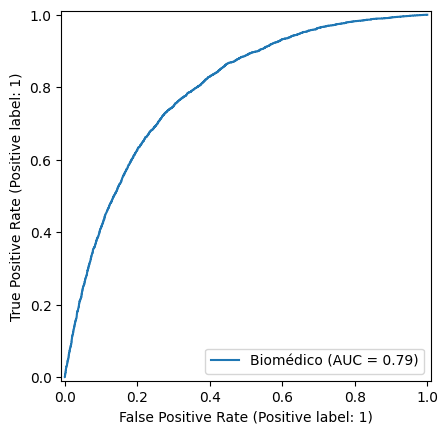

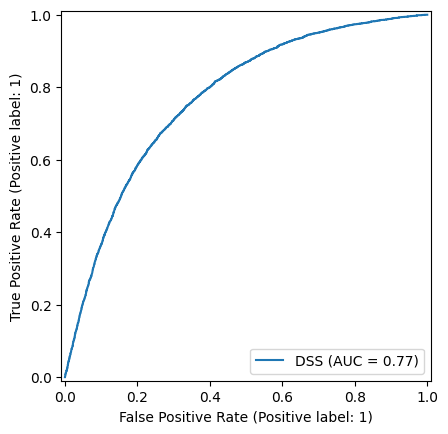

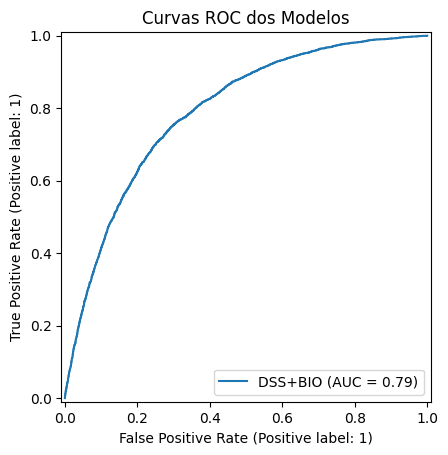

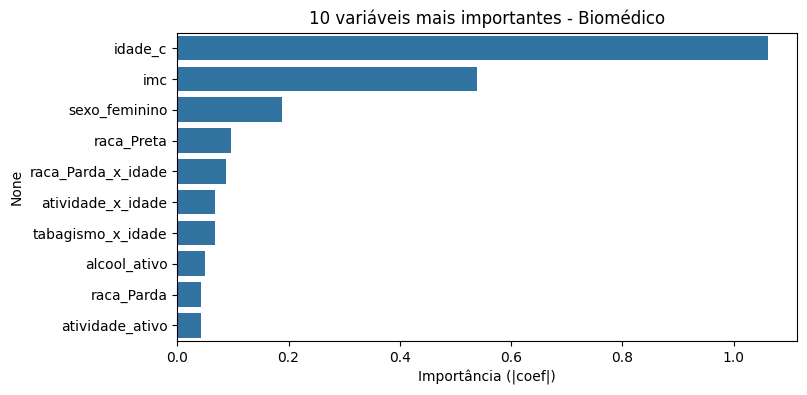

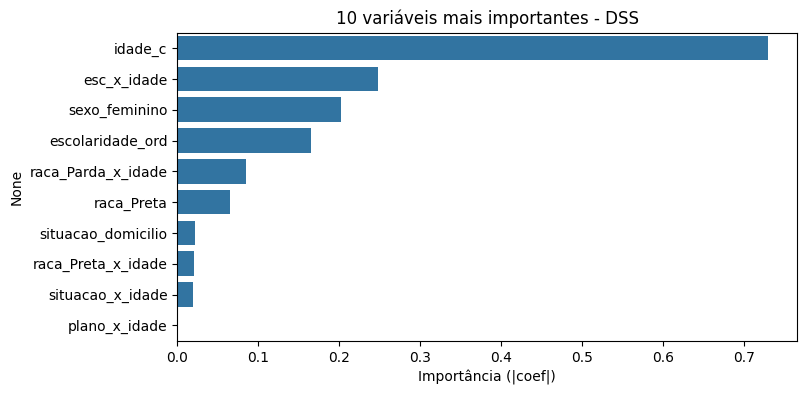

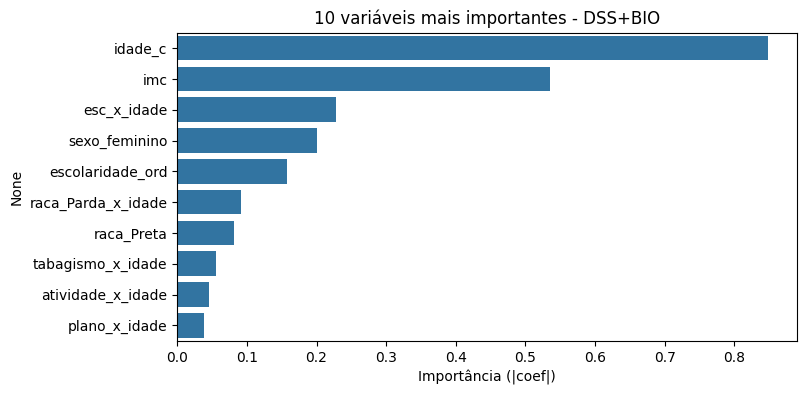

In [120]:
# 10. Validação cruzada (k-fold)
from sklearn.model_selection import cross_val_score
from sklearn.metrics import recall_score

cv_results = {}
for nome, X, y, modelo in [
    ("Biomédico", X_bio, y, pipeline_bio),
    ("DSS", X_dss, y, pipeline_dss),
    ("DSS+BIO", X_dss_bio, y, pipeline_dss_bio)
]:
    scores = cross_val_score(modelo, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[nome] = scores
    print(f"{nome}: Média AUC = {scores.mean():.3f} | Desvio padrão = {scores.std():.3f}")

# 4b. Análise detalhada das matrizes de confusão
from sklearn.metrics import confusion_matrix
import pandas as pd

def confusion_details(y_true, y_pred, nome):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\nMatriz de confusão - {nome}")
    print(pd.DataFrame(cm, columns=["Predito 0", "Predito 1"], index=["Real 0", "Real 1"]))
    print(f"Falsos Positivos: {fp}")
    print(f"Falsos Negativos: {fn}")
    return fp, fn

fp_bio, fn_bio = confusion_details(y_bio_test, y_bio_pred, "Biomédico")
fp_dss, fn_dss = confusion_details(y_dss_test, y_dss_pred, "DSS")
fp_dss_bio, fn_dss_bio = confusion_details(y_dss_bio_test, y_dss_bio_pred, "DSS+BIO")

# Tabela comparativa
resultados = pd.DataFrame({
    'Modelo': ['Biomédico', 'DSS', 'DSS+BIO'],
    'AUC (test)': [roc_auc_score(y_bio_test, y_bio_prob), roc_auc_score(y_dss_test, y_dss_prob), roc_auc_score(y_dss_bio_test, y_dss_bio_prob)],
    'AUC (CV média)': [cv_results['Biomédico'].mean(), cv_results['DSS'].mean(), cv_results['DSS+BIO'].mean()],
    'AUC (CV std)': [cv_results['Biomédico'].std(), cv_results['DSS'].std(), cv_results['DSS+BIO'].std()],
    'Accuracy': [accuracy_score(y_bio_test, y_bio_pred), accuracy_score(y_dss_test, y_dss_pred), accuracy_score(y_dss_bio_test, y_dss_bio_pred)],
    'Recall': [recall_score(y_bio_test, y_bio_pred), recall_score(y_dss_test, y_dss_pred), recall_score(y_dss_bio_test, y_dss_bio_pred)],
    'Falsos Positivos': [fp_bio, fp_dss, fp_dss_bio],
    'Falsos Negativos': [fn_bio, fn_dss, fn_dss_bio]
})
print("\nTabela comparativa dos modelos:")
display(resultados)

# Gráfico ROC
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_bio_test, y_bio_prob, name='Biomédico')
RocCurveDisplay.from_predictions(y_dss_test, y_dss_prob, name='DSS')
RocCurveDisplay.from_predictions(y_dss_bio_test, y_dss_bio_prob, name='DSS+BIO')
plt.title('Curvas ROC dos Modelos')
plt.show()

# Gráfico de importância das variáveis (coeficientes absolutos)
def plot_importancia(coef, nome):
    coef_abs = coef.abs().sort_values(ascending=False)
    plt.figure(figsize=(8,4))
    sns.barplot(x=coef_abs.values[:10], y=coef_abs.index[:10])
    plt.title(f'10 variáveis mais importantes - {nome}')
    plt.xlabel('Importância (|coef|)')
    plt.show()

plot_importancia(coef_bio, 'Biomédico')
plot_importancia(coef_dss, 'DSS')
plot_importancia(coef_dss_bio, 'DSS+BIO')

In [121]:
# 10. Validação cruzada (k-fold)
from sklearn.model_selection import cross_val_score

cv_results = {}
for nome, X, y, modelo in [
    ("Biomédico", X_bio, y, pipeline_bio),
    ("DSS", X_dss, y, pipeline_dss),
    ("DSS+BIO", X_dss_bio, y, pipeline_dss_bio)
]:
    scores = cross_val_score(modelo, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[nome] = scores
    print(f"{nome}: Média AUC = {scores.mean():.3f} | Desvio padrão = {scores.std():.3f}")

Biomédico: Média AUC = 0.797 | Desvio padrão = 0.003
DSS: Média AUC = 0.772 | Desvio padrão = 0.005
DSS+BIO: Média AUC = 0.797 | Desvio padrão = 0.002


In [122]:
# 4b. Análise detalhada das matrizes de confusão
from sklearn.metrics import confusion_matrix
import pandas as pd

def confusion_details(y_true, y_pred, nome):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\nMatriz de confusão - {nome}")
    print(pd.DataFrame(cm, columns=["Predito 0", "Predito 1"], index=["Real 0", "Real 1"]))
    print(f"Falsos Positivos: {fp}")
    print(f"Falsos Negativos: {fn}")
    return fp, fn

fp_bio, fn_bio = confusion_details(y_bio_test, y_bio_pred, "Biomédico")
fp_dss, fn_dss = confusion_details(y_dss_test, y_dss_pred, "DSS")
fp_dss_bio, fn_dss_bio = confusion_details(y_dss_bio_test, y_dss_bio_pred, "DSS+BIO")


Matriz de confusão - Biomédico
        Predito 0  Predito 1
Real 0       7468       2961
Real 1       1170       3262
Falsos Positivos: 2961
Falsos Negativos: 1170

Matriz de confusão - DSS
        Predito 0  Predito 1
Real 0       7203       3226
Real 1       1239       3193
Falsos Positivos: 3226
Falsos Negativos: 1239

Matriz de confusão - DSS+BIO
        Predito 0  Predito 1
Real 0       7426       3003
Real 1       1144       3288
Falsos Positivos: 3003
Falsos Negativos: 1144


In [123]:
# 4. Teste de significância da AUC (bootstrap)
from sklearn.utils import resample

def bootstrap_auc(y_true, y_score, n_bootstraps=1000, random_state=42):
    np.random.seed(random_state)
    bootstrapped_scores = []
    for i in range(n_bootstraps):
        indices = resample(np.arange(len(y_true)), replace=True)
        if len(np.unique(y_true[indices])) < 2:
            continue
        score = roc_auc_score(y_true[indices], y_score[indices])
        bootstrapped_scores.append(score)
    return np.percentile(bootstrapped_scores, [2.5, 97.5]), np.mean(bootstrapped_scores)

# Calcular intervalos de confiança para cada modelo
aucs = {}
for nome, y_true, y_score in [
    ("Biomédico", y_bio_test.values, y_bio_prob),
    ("DSS", y_dss_test.values, y_dss_prob),
    ("DSS+BIO", y_dss_bio_test.values, y_dss_bio_prob)
]:
    ci, mean_auc = bootstrap_auc(y_true, y_score)
    aucs[nome] = (mean_auc, ci)
    print(f"AUC {nome}: {mean_auc:.3f} (IC 95%: {ci[0]:.3f} - {ci[1]:.3f})")

AUC Biomédico: 0.792 (IC 95%: 0.784 - 0.800)
AUC DSS: 0.770 (IC 95%: 0.762 - 0.778)
AUC DSS+BIO: 0.793 (IC 95%: 0.785 - 0.801)
